In [1]:
import os
os.chdir("./..")

from utils.config import load_config
from pathlib import Path

confpath = Path("/home/ppavlik/repos/nowcasting-SVK-dualpol/config/MF-3D-U-Net_altitude_wise")
dsconf = load_config(confpath / "datasets.yaml")
modelconf = load_config(confpath / "model.yaml")

import datasets.SlovakDatasetDualPol as SlovakDatasetDualPol

ds = SlovakDatasetDualPol(split="test", **dsconf.SHMUDataset)

from models import MF3DUNetAltitudeWise
import torch

checkpoint = Path("/projects/p1364-25-2/checkpoints/Nowcasting_SVK_dualpol/Layers8/epoch=20-step=21000.ckpt")

model = MF3DUNetAltitudeWise.load_from_checkpoint(checkpoint, config=modelconf, map_location=torch.device('cpu'))
model = model.to(torch.device('cuda:0'))

Pysteps configuration file found at: /home/ppavlik/miniconda3/envs/nowcasting/lib/python3.12/site-packages/pysteps/pystepsrc



In [2]:
class SpoofTrainer(object):
    pass

spoof_trainer = SpoofTrainer()
spoof_trainer.training = False
spoof_trainer.predicting = False
spoof_trainer.testing = True
spoof_trainer.state = SpoofTrainer()
spoof_trainer.state.stage = 'test'

spoof_trainer.datamodule = SpoofTrainer()
spoof_trainer.datamodule.test_dataset = ds

model._trainer = spoof_trainer
model.eval()

MF3DUNetAltitudeWise(
  (network): RainNet3DNoNorm(
    (conv): ModuleDict(
      (1): Sequential(
        (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, padding_mode=replicate)
        (1): ReLU()
        (2): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, padding_mode=replicate)
        (3): ReLU()
      )
      (2): Sequential(
        (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, padding_mode=replicate)
        (1): ReLU()
        (2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, padding_mode=replicate)
        (3): ReLU()
      )
      (3): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, padding_mode=replicate)
        (1): ReLU()
        (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=same, padding_mode=replicate)
        (3): ReLU()
      )
      (4): Sequential(
        (0): Conv3d(64, 128, kernel_size=(3, 3,

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import os
import torch
import torch.nn as nn
from pysteps import motion
from torchmetrics.regression import PearsonCorrCoef
import numpy as np
from torchvision.transforms.functional import center_crop

mse = nn.MSELoss()

def _count_mf_corr(i):
    pearson = PearsonCorrCoef().to(torch.device('cuda:0'))
    
    idx = [i]

    x, y, _ = ds[idx[0]]
    x = center_crop(x, 512)
    y = center_crop(y, 512)

    sample_1km = x[:,0,0]
    sample_3km = x[:,0,2]

    sample_mask_1km = sample_1km.mean(dim=0) > -15
    sample_mask_1km = torch.stack([sample_mask_1km, sample_mask_1km])

    sample_mask_3km = sample_3km.mean(dim=0) > -15
    sample_mask_3km = torch.stack([sample_mask_3km, sample_mask_3km])

    sample_mask = sample_mask_1km | sample_mask_3km

    x = x.unsqueeze(0).to(torch.device('cuda:0'))
    y = y.unsqueeze(0).to(torch.device('cuda:0'))

    with torch.no_grad():
        y_hat, mf = model.predict_step((x, y, idx), idx)

    motion_field_1km = mf[0].squeeze()
    motion_field_3km = mf[2].squeeze()

    pearson_corr = pearson(motion_field_1km[sample_mask].flatten(), motion_field_3km[sample_mask].flatten())

    mse_mf_loss = mse(motion_field_1km[sample_mask], motion_field_3km[sample_mask])

    mse_loss = mse(y_hat.squeeze().nan_to_num(), ds.invScaler(y.squeeze().nan_to_num()))
    
    return pearson_corr, mse_mf_loss, mse_loss

In [81]:
pearson_corrs = torch.zeros(len(ds))
mse_mf_losses = torch.zeros(len(ds))
mse_losses = torch.zeros(len(ds))

for i in tqdm(range(len(ds))):
    pearson_corr, mse_mf_loss, mse_loss = _count_mf_corr(i)
    pearson_corrs[i] = pearson_corr
    mse_mf_losses[i] = mse_mf_loss
    mse_losses[i] = mse_loss

  0%|          | 13/3694 [01:09<5:29:16,  5.37s/it]


KeyboardInterrupt: 

In [82]:
np.savez_compressed("altitude_wise_mf_sample_wise_eval.npz",
                    pearson_corrs=pearson_corrs.cpu().numpy(),
                    mse_mf_losses=mse_mf_losses.cpu().numpy(),
                    mse_losses=mse_losses.cpu().numpy())

In [2]:
import numpy as np

pearson_corrs, mse_mf_losses, mse_losses = np.load("/home/ppavlik/repos/nowcasting-SVK-dualpol/altitude_wise_mf_sample_wise_eval.npz").values()

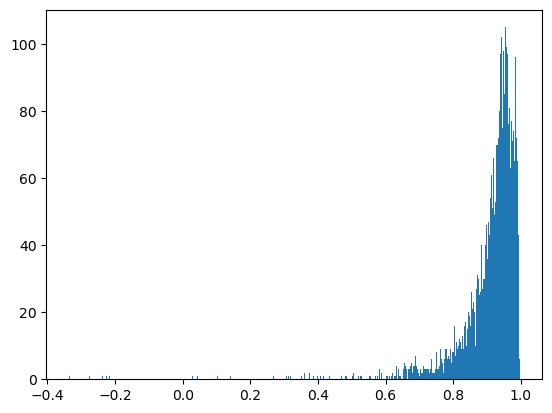

In [4]:
import matplotlib.pyplot as plt

#df.plot.hist(y="mf_corrs", bins=512)
plt.hist(pearson_corrs, bins=512)
#plt.yscale('log')
plt.show()